Wine Clustering Assisgnemnt

Objective 1

In [1]:
#Imports 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
 
from itertools import permutations
 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import (confusion_matrix, classification_report,accuracy_score,recall_score,silhouette_score, davies_bouldin_score,calinski_harabasz_score)
from sklearn.decomposition import PCA
 
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet
from scipy.spatial.distance import pdist
from scipy.stats import pearsonr

In [2]:
# Load data
file_path = "Wine data.xlsx"

# Read both sheets
red_wine = pd.read_excel(file_path, sheet_name="Red Wine")
white_wine = pd.read_excel(file_path, sheet_name="White Wine")

In [3]:
red_wine.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [4]:
white_wine.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


In [5]:
#Merge datasets & add ground-truth label

red_wine_c = red_wine.copy();   red_wine_c["wine_type"]   = 0 
white_wine_c = white_wine.copy();   white_wine_c["wine_type"]   = 1

# Merge datasets
wine_df = pd.concat([red_wine_c, white_wine_c], ignore_index=True)

print("Combined Dataset Shape:")
print(wine_df.shape)


Combined Dataset Shape:
(6497, 13)


In [6]:
wine_df.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,wine_type
0,7.4,0.7,0.0,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [7]:
#Check Misiing Values
print("\nMissing Values:")
print(wine_df.isnull().sum())


Missing Values:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
wine_type               0
dtype: int64


Preapare Fatures

In [8]:
# Use only first 11 chemical attributes
X = wine_df.iloc[:, 0:11]
# Actual labels
y_true = wine_df["wine_type"] # ground truth

Standerdize Data

In [9]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means (k=2)

In [10]:
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=20
)

clusters = kmeans.fit_predict(X_scaled)

Confison Matrix

In [11]:
cm = confusion_matrix(y_true, clusters)
tn, fp, fn, tp = cm.ravel()

In [12]:
print("\nConfusion Matrix (rows = True label, cols = Predicted):")
print(pd.DataFrame(cm,
                   index=["True Red", "True White"],
                   columns=["Pred White", "Pred Red"]).to_string())


Confusion Matrix (rows = True label, cols = Predicted):
            Pred White  Pred Red
True Red            24      1575
True White        4831        67


Accuracy

In [13]:
acc1 = accuracy_score(y_true, clusters)
acc2 = accuracy_score(y_true, 1 - clusters)

accuracy = max(acc1, acc2)

print("\nClassification Accuracy:")
print(round(accuracy, 4))


Classification Accuracy:
0.986


Sensitivity/ Recall

In [14]:
recall1 = recall_score(y_true, clusters)
recall2 = recall_score(y_true, 1 - clusters)

sensitivity = max(recall1, recall2)

print("\nSensitivity (Recall):")
print(round(sensitivity, 4))


Sensitivity (Recall):
0.9863


Plot confusion matrix

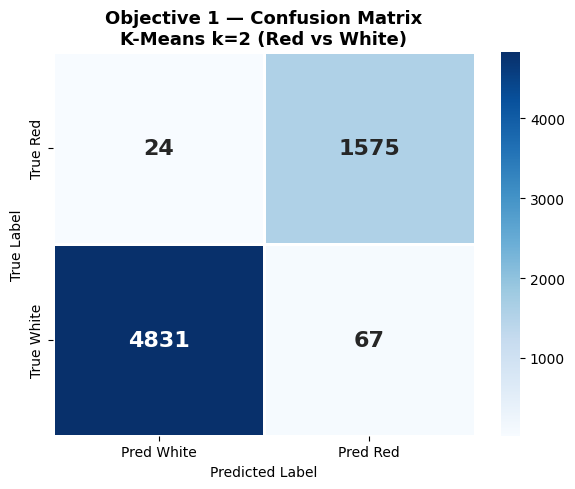

In [15]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", linewidths=1,
            xticklabels=["Pred White", "Pred Red"],
            yticklabels=["True Red", "True White"],
            annot_kws={"size": 16, "weight": "bold"}, ax=ax)
ax.set_title("Objective 1 — Confusion Matrix\nK-Means k=2 (Red vs White)",
             fontsize=13, fontweight="bold")
ax.set_ylabel("True Label"); ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("obj1_confusion_matrix.png")
plt.show()

Objective 2

In [16]:
# Use white wine dataset only
white_df = white_wine.copy()

In [17]:
white_df.head(1)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.001,3.0,0.45,8.8,6


Selecting Features

In [18]:
X_white = white_df.iloc[:, 0:11]

Standardize

In [19]:
scaler_white = StandardScaler()
X_white_scaled = scaler_white.fit_transform(X_white)


Elbow Method

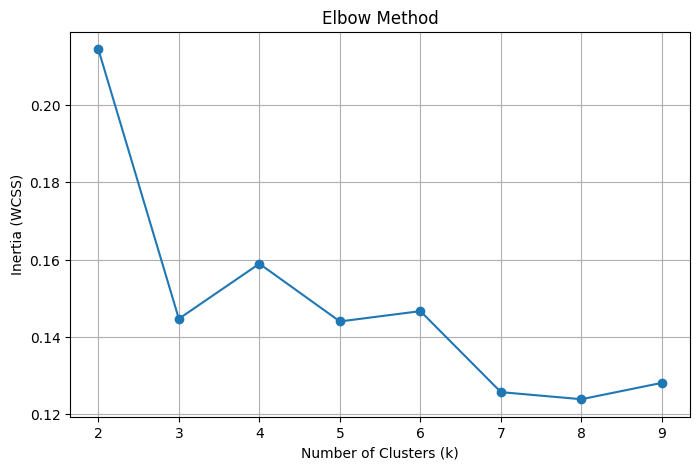

In [21]:
sil_scores = []

K_range = range(2, 10)

for k in K_range:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = km.fit_predict(X_white_scaled)

    sil = silhouette_score(X_white_scaled, labels)

    sil_scores.append(sil)

# Plot Elbow Curve
plt.figure(figsize=(8,5))
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (WCSS)")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Silhouette Scores

In [22]:
silhouette_table = pd.DataFrame({
    "k": list(K_range),
    "Silhouette Score": sil_scores
})

print("\nSilhouette Scores:")
print(silhouette_table)


Silhouette Scores:
   k  Silhouette Score
0  2          0.214477
1  3          0.144663
2  4          0.158925
3  5          0.143973
4  6          0.146645
5  7          0.125661
6  8          0.123828
7  9          0.128075


Evaluate Candidate Clusters

In [49]:
#Run K-Means for Both Candidates (k=2 and k=4)

candidates = [2, 4]
km_results = {}

print("K-Means Results for Candidate k Values")

for k in candidates:
    km  = KMeans(n_clusters=k, n_init=20, random_state=42)
    km.fit(X_white_scaled)
    sil = silhouette_score(X_white_scaled, km.labels_,
                           sample_size=2000, random_state=42)
    km_results[k] = {
        "model"   : km,
        "labels"  : km.labels_,
        "sil"     : sil,
        "inertia" : km.inertia_,
    }
    print(f"\n  k = {k}")
    print(f"  WCSS (Inertia)   : {km.inertia_:.2f}")
    print(f"  Silhouette Score : {sil:.4f}")

    # Cluster sizes
    unique, counts = np.unique(km.labels_, return_counts=True)
    print(f"  Cluster Sizes    : "
          f"{dict(zip([f'Cluster {u}' for u in unique], counts))}")


K-Means Results for Candidate k Values

  k = 2
  WCSS (Inertia)   : 42548.67
  Silhouette Score : 0.2114
  Cluster Sizes    : {'Cluster 0': 1957, 'Cluster 1': 2941}

  k = 4
  WCSS (Inertia)   : 35986.90
  Silhouette Score : 0.1576
  Cluster Sizes    : {'Cluster 0': 1698, 'Cluster 1': 1631, 'Cluster 2': 107, 'Cluster 3': 1462}


In [51]:
# Validate: Which k is More Accurate?

print("Validation — Silhouette Score Comparison")

print(f"\n  k=2 Silhouette : {km_results[2]['sil']:.4f}")
print(f"  k=4 Silhouette : {km_results[4]['sil']:.4f}")

winner_k = max(candidates, key=lambda k: km_results[k]["sil"])
loser_k  = min(candidates, key=lambda k: km_results[k]["sil"])


Validation — Silhouette Score Comparison

  k=2 Silhouette : 0.2114
  k=4 Silhouette : 0.1576


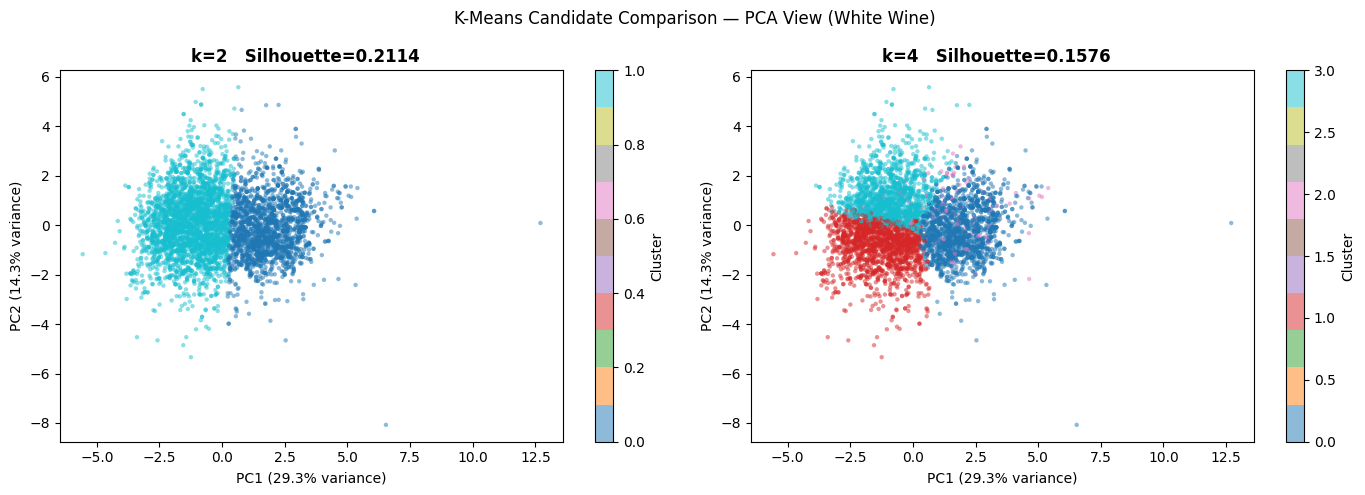

In [54]:
# PCA Scatter: Side by Side Comparison

pca      = PCA(n_components=2, random_state=42)
X_pca    = pca.fit_transform(X_white_scaled)
ev1, ev2 = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, k in zip(axes, candidates):
    ttag = "WINNER" if k == winner_k else ""
    sc  = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                     c=km_results[k]["labels"],
                     cmap="tab10", alpha=0.5,
                     edgecolors="none", s=10)
    ax.set_title(f"k={k}   Silhouette={km_results[k]['sil']:.4f}  {tag}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(f"PC1 ({ev1:.1f}% variance)")
    ax.set_ylabel(f"PC2 ({ev2:.1f}% variance)")
    plt.colorbar(sc, ax=ax, label="Cluster")

plt.suptitle("K-Means Candidate Comparison — PCA View (White Wine)")
plt.tight_layout()
plt.show()

Mean Of Each ATttribute Per Cluster

In [57]:
final_kmeans = KMeans(
    n_clusters=winner_k,
    random_state=42,
    n_init=20
)

# Generate cluster labels
final_labels = final_kmeans.fit_predict(X_white_scaled)

# Add labels to dataframe
white_df["Cluster"] = final_labels

print(f"K-Means applied with winning k = {winner_k}")
print(f"\nCluster sizes:")
print(white_df["Cluster"].value_counts().sort_index())

K-Means applied with winning k = 2

Cluster sizes:
Cluster
0    1957
1    2941
Name: count, dtype: int64


In [58]:
cluster_means = white_df.groupby("Cluster").mean()

print("\nCluster Means:")
print(cluster_means)


Cluster Means:
         fixed acidity  volatile acidity  citric acid  residual sugar  \
Cluster                                                                 
0             7.003219          0.282966     0.362534       10.692131   
1             6.756018          0.275097     0.315332        3.529633   

         chlorides  free sulfur dioxide  total sulfur dioxide   density  \
Cluster                                                                   
0         0.054475            45.464997            170.897547  0.996861   
1         0.039982            28.549473            116.709963  0.992142   

               pH  sulphates    alcohol   quality  
Cluster                                            
0        3.157839   0.496679   9.541185  5.603475  
1        3.208514   0.485301  11.161775  6.060524  


Quality Consistency Check

In [70]:
quality_means = white_df.groupby("Cluster")["quality"].mean()

print("\nAverage Quality Per Cluster:")
print(quality_means)


Average Quality Per Cluster:
Cluster
0    5.603475
1    6.060524
Name: quality, dtype: float64


Objective 3 - Hierarchical Clustering

Sample data for hierarchical clustering

In [27]:
white_sample = white_df.sample(
    n=500,
    random_state=42
)

# Features only
X_hier = white_sample.iloc[:, 0:11]

# Standardize
scaler_hier = StandardScaler()

X_hier_scaled = scaler_hier.fit_transform(X_hier)

In [34]:
# Sample 500 wines 
RNG    = np.random.RandomState(42)
idx_s  = RNG.choice(len(X_hier_scaled), size=500, replace=False)
X_hier = X_hier_scaled[idx_s]


In [35]:
# Compute linkage for all 3 methods
METHODS  = ["single", "complete", "average"]
Z_dict   = {}
coph_r   = {}
coph_vec = {}

for method in METHODS:
    Z = linkage(X_hier, method=method, metric="euclidean")
    Z_dict[method] = Z
    c, cv = cophenet(Z, pdist(X_hier))
    coph_r[method]   = c
    coph_vec[method] = cv
    print(f"  {method:8s} — Cophenetic correlation = {c:.4f}")

  single   — Cophenetic correlation = 0.6636
  complete — Cophenetic correlation = 0.5036
  average  — Cophenetic correlation = 0.7356


Dengrogram

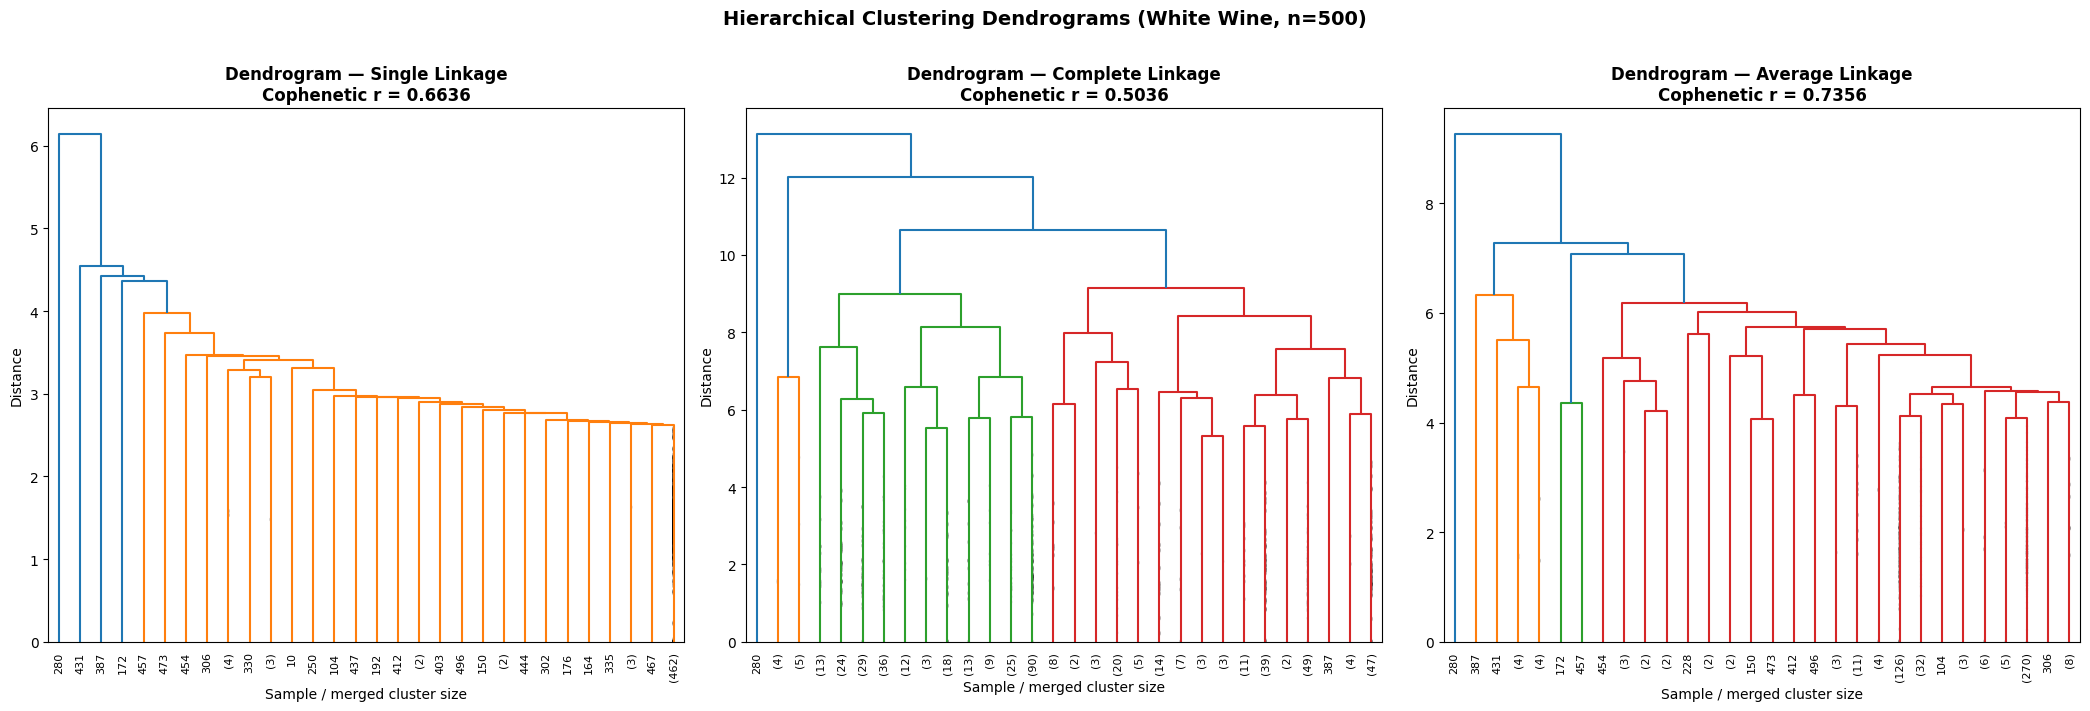

In [37]:
#  Plot all 3 dendrograms 
fig, axes = plt.subplots(1, 3, figsize=(21, 7))

for ax, method in zip(axes, METHODS):
    dendrogram(
        Z_dict[method],
        ax=ax,
        truncate_mode="lastp",
        p=30,
        leaf_rotation=90,
        leaf_font_size=8,
        show_contracted=True,
        color_threshold=0.7 * max(Z_dict[method][:, 2]),
    )
    ax.set_title(f"Dendrogram — {method.capitalize()} Linkage\n"
                 f"Cophenetic r = {coph_r[method]:.4f}",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Sample / merged cluster size")
    ax.set_ylabel("Distance")

plt.suptitle("Hierarchical Clustering Dendrograms "
             "(White Wine, n=500)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("obj3_dendrograms.png", bbox_inches="tight")
plt.show()

Cophenetic Correlation

  Single     : 0.6636
  Complete   : 0.5036
  Average    : 0.7356


Text(0.5, 1.0, 'Cophenetic Correlation by Linkage Method\n')

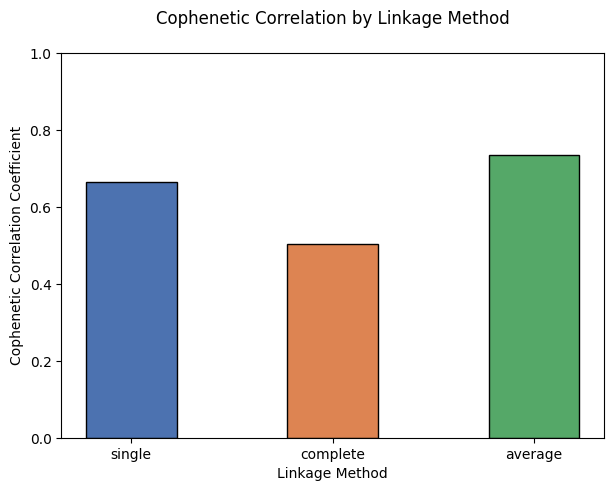

In [45]:
for method in METHODS:
    print(f"  {method.capitalize():10s} : {coph_r[method]:.4f}")

# ── Bar chart of cophenetic correlations ──────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
colors = ["#4C72B0", "#DD8452", "#55A868"]
bars   = ax.bar(METHODS,
                [coph_r[m] for m in METHODS],
                color=colors, edgecolor="black", width=0.45)
ax.set_ylim(0, 1.0)
ax.set_ylabel("Cophenetic Correlation Coefficient")
ax.set_xlabel("Linkage Method")
ax.set_title("Cophenetic Correlation by Linkage Method\n")

In [41]:
n_m      = len(METHODS)
corr_mat = np.ones((n_m, n_m))

for i, m1 in enumerate(METHODS):
    for j, m2 in enumerate(METHODS):
        if i != j:
            r, _ = pearsonr(coph_vec[m1], coph_vec[m2])
            corr_mat[i, j] = r

# Print correlation matrix
print("Pairwise Cophenetic Distance Correlations")
print("(corrplot equivalent)")

df_corr = pd.DataFrame(corr_mat,
                       index=METHODS,
                       columns=METHODS).round(4)
print(df_corr.to_string())

print("\nPairwise values:")
for i, m1 in enumerate(METHODS):
    for j, m2 in enumerate(METHODS):
        if j > i:
            print(f"  {m1} vs {m2} : r = {corr_mat[i,j]:.4f}")

Pairwise Cophenetic Distance Correlations
(corrplot equivalent)
          single  complete  average
single    1.0000    0.2671   0.7617
complete  0.2671    1.0000   0.4857
average   0.7617    0.4857   1.0000

Pairwise values:
  single vs complete : r = 0.2671
  single vs average : r = 0.7617
  complete vs average : r = 0.4857


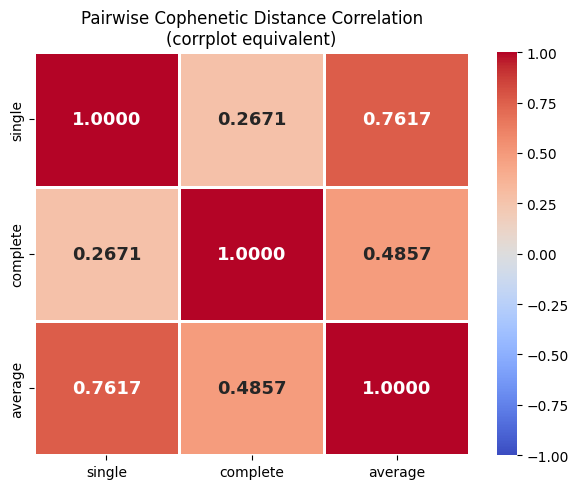

In [44]:
#Corrplot heatmap 
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr_mat,
            xticklabels=METHODS,
            yticklabels=METHODS,
            annot=True,
            fmt=".4f",
            cmap="coolwarm",
            center=0,
            vmin=-1, vmax=1,
            linewidths=1,
            linecolor="white",
            annot_kws={"size": 13, "weight": "bold"},
            ax=ax)
ax.set_title("Pairwise Cophenetic Distance Correlation\n"
             "(corrplot equivalent)")
plt.tight_layout()
plt.show()